In [9]:
import numpy as np
import sympy as sym

In [ ]:
sym.Matrix([1,2,3,4,5])

Matrix([
[1],
[2],
[3],
[4],
[5]])

In [ ]:
sym.Matrix([[0], [0], [0], [1]])

Matrix([
[0],
[0],
[0],
[1]])

In [5]:
def HomRot_x(Rx):
    return sym.Matrix([
                    [1, 0,           0,            0],
                    [0, sym.cos(Rx), -sym.sin(Rx), 0],
                    [0, sym.sin(Rx), sym.cos(Rx),  0],
                    [0, 0,           0,            1]  
                    ])

def HomRot_y(Ry):
    return sym.Matrix([
                    [sym.cos(Ry),  0, sym.sin(Ry), 0],
                    [0,            1, 0,           0],
                    [-sym.sin(Ry), 0, sym.cos(Ry), 0],
                    [0,            0, 0,           1]  
                    ])

def HomRot_z(Rz):
    return sym.Matrix([
                    [sym.cos(Rz), -sym.sin(Rz), 0, 0],
                    [sym.sin(Rz), sym.cos(Rz),  0, 0],
                    [0,           0,            1, 0],
                    [0,           0,            0, 1]
                    ])

def HomTransl_x(Tx):
    return sym.Matrix([
                    [1, 0, 0, Tx],
                    [0, 1, 0, 0],
                    [0, 0, 1, 0],
                    [0, 0, 0, 1]
                    ])

def HomTransl_y(Ty):
    return sym.Matrix([
                    [1, 0, 0, 0 ],
                    [0, 1, 0, Ty],
                    [0, 0, 1, 0 ],
                    [0, 0, 0, 1 ]
                    ])

def HomTransl_z(Tz):
    return sym.Matrix([
                    [1, 0, 0, 0 ],
                    [0, 1, 0, 0 ],
                    [0, 0, 1, Tz],
                    [0, 0, 0, 1 ] 
                    ])

In [7]:
print('HomTransl_y(17):')
HomTransl_y(17)

HomTransl_y(17):


Matrix([
[1, 0, 0,  0],
[0, 1, 0, 17],
[0, 0, 1,  0],
[0, 0, 0,  1]])

In [8]:
print('HomTransl_x(17):')
HomTransl_x(17)

HomTransl_x(17):


Matrix([
[1, 0, 0, 17],
[0, 1, 0,  0],
[0, 0, 1,  0],
[0, 0, 0,  1]])

In [10]:
print('HomRot_y(pi/3):')
HomRot_y(np.pi/3)

HomRot_y(pi/3):


Matrix([
[               0.5, 0, 0.866025403784439, 0],
[                 0, 1,                 0, 0],
[-0.866025403784439, 0,               0.5, 0],
[                 0, 0,                 0, 1]])

In [11]:
print('HomRot_x(pi/3):')
HomRot_x(np.pi/3)

HomRot_x(pi/3):


Matrix([
[1,                 0,                  0, 0],
[0,               0.5, -0.866025403784439, 0],
[0, 0.866025403784439,                0.5, 0],
[0,                 0,                  0, 1]])

In [12]:
print('HomRot_z(pi/3):')
HomRot_z(np.pi/3)

HomRot_z(pi/3):


Matrix([
[              0.5, -0.866025403784439, 0, 0],
[0.866025403784439,                0.5, 0, 0],
[                0,                  0, 1, 0],
[                0,                  0, 0, 1]])

In [13]:
def Rot_x(Rx):
    return sym.Matrix([
                    [1,           0,            0],
                    [0, sym.cos(Rx), -sym.sin(Rx)],
                    [0, sym.sin(Rx),  sym.cos(Rx)]
                    ])

def Rot_y(Ry):
    return sym.Matrix([
                    [sym.cos(Ry),  0, sym.sin(Ry)],
                    [0,            1,           0],
                    [-sym.sin(Ry), 0, sym.cos(Ry)],
                    ])

def Rot_z(Rz):
    return sym.Matrix([
                    [sym.cos(Rz), -sym.sin(Rz), 0],
                    [sym.sin(Rz),  sym.cos(Rz), 0],
                    [          0,            0, 1]
                    ])

In [14]:
print('Rot_x(pi/3):')
Rot_x(np.pi/3)

Rot_x(pi/3):


Matrix([
[1,                 0,                  0],
[0,               0.5, -0.866025403784439],
[0, 0.866025403784439,                0.5]])

In [15]:
print('Rot_y(pi/3):')
Rot_y(np.pi/3)

Rot_y(pi/3):


Matrix([
[               0.5, 0, 0.866025403784439],
[                 0, 1,                 0],
[-0.866025403784439, 0,               0.5]])

In [16]:
print('Rot_z(pi/3):')
Rot_z(np.pi/3)

Rot_z(pi/3):


Matrix([
[              0.5, -0.866025403784439, 0],
[0.866025403784439,                0.5, 0],
[                0,                  0, 1]])

In [26]:
from siriuspy.devices import CAXCtrl, DVF

cax = CAXCtrl()
det = cax.dvf_B1

det["PP01:E.CNEN"]

1

In [23]:
import epics

# E : caustic
# F : lens

pvbase = 'CAX:B:PP01:E'
pvbase = 'CAX:B:PP01:F'

vrs = ['RBV', 'VAL', 'LLM', 'HLM', 'DESC', 'CNEN']
for v in vrs:
    print(f"{v}: {epics.caget(f'{pvbase}.{v}')}")

RBV: 3.86400405
VAL: 3.864
LLM: 1.9463340000000002
HLM: 16.86418
DESC: Lens DVF2
CNEN: 1


In [34]:
from datetime import datetime

datetime.now().strftime("%Y-%m-%d %H:%M:%S")

'2026-02-27 12:44:58'

In [14]:
from siriuspy.devices import CAXCtrl

cax = CAXCtrl()
# vars(cax.mirror.PVS)
cax.mirror.PVS
# vars(cax.dvf_B1)
# cax.dvf_B1

namespace(RY_SP='A:PP01:A.VAL',
          RY_RB='A:PP01:A.VAL',
          RY_MON='A:PP01:A.RBV',
          RY_STOP='A:PP01:A.STOP',
          TX_SP='A:PP01:B.VAL',
          TX_RB='A:PP01:B.VAL',
          TX_MON='A:PP01:B.RBV',
          TX_STOP='A:PP01:B.STOP',
          Y1_SP='A:PP01:C.VAL',
          Y1_RB='A:PP01:C.VAL',
          Y1_MON='A:PP01:C.RBV',
          Y1_STOP='A:PP01:C.STOP',
          Y2_SP='A:PP01:D.VAL',
          Y2_RB='A:PP01:D.VAL',
          Y2_MON='A:PP01:D.RBV',
          Y2_STOP='A:PP01:D.STOP',
          Y3_SP='A:PP01:E.VAL',
          Y3_RB='A:PP01:E.VAL',
          Y3_MON='A:PP01:E.RBV',
          Y3_STOP='A:PP01:E.STOP',
          PHOTOCOLLECTOR='A:RIO01:9215A:ai0',
          TEMP0_MON='A:RIO01:9226B:temp0',
          TEMP1_MON='A:RIO01:9226B:temp1',
          TEMP2_MON='A:RIO01:9226B:temp2',
          TEMP3_MON='A:RIO01:9226B:temp3',
          TEMP4_MON='A:RIO01:9226B:temp4',
          TEMP_SP='A:RIO01:M1_CtrltempSp',
          TEMP_RB='A:RIO01:M1_Ctrlte

In [15]:
# import sys
# dev_parent = "/opt/micromamba/envs/sirius/repos/dev-packages"
# # if dev_parent not in sys.path:
# sys.path.insert(0, dev_parent)

# import siriuspy
from siriuspy.devices.beamlines.mirror import _PVAccessor as pva
# from siriuspy.devices.beamlines.mirror import MirrorBase as mb

pva.__module__
# print(siriuspy.__file__)

ImportError: cannot import name '_PVAccessor' from 'siriuspy.devices.beamlines.mirror' (/opt/micromamba/envs/sirius/lib/python3.9/site-packages/siriuspy/devices/beamlines/mirror.py)

In [10]:
import sys, os

print("=== PYTHONPATH env var ===")
print(os.environ.get('PYTHONPATH', '(not set)'))

print("\n=== sys.path ===")
for p in sys.path:
    print(p)

print("\n=== siriuspy location ===")
siriuspy_mod = sys.modules.get('siriuspy')
if siriuspy_mod:
    print(f"  __file__ : {getattr(siriuspy_mod, '__file__', '(no __file__)')}")
    print(f"  __path__ : {getattr(siriuspy_mod, '__path__', '(no __path__)')}")
else:
    print("  siriuspy not yet in sys.modules")

print("\n=== all siriuspy submodule files ===")
for name, mod in sorted(sys.modules.items()):
    if 'siriuspy' in name:
        f = getattr(mod, '__file__', None) or getattr(mod, '__path__', None)
        print(f"  {name:45} : {f}")

=== PYTHONPATH env var ===
/opt/micromamba/envs/sirius/repos/dev-packages/siriuspy:/opt/micromamba/envs/sirius/repos/dev-packages:/opt/micromamba/envs/sirius/repos/dev-packages/siriuspy:/opt/micromamba/envs/sirius/repos/dev-packages

=== sys.path ===
/home/ABTLUS/arnaldo.filho/repos/cax-scripts
/opt/micromamba/envs/sirius/repos/dev-packages
/opt/micromamba/envs/sirius/lib/python39.zip
/opt/micromamba/envs/sirius/lib/python3.9
/opt/micromamba/envs/sirius/lib/python3.9/lib-dynload

/opt/micromamba/envs/sirius/lib/python3.9/site-packages
/home/ABTLUS/sergio.lordano/software/mathphys
/opt/micromamba/envs/sirius/lib/python3.9/site-packages/scipy-1.13.0-py3.9-linux-x86_64.egg
/opt/micromamba/envs/sirius/lib/python3.9/site-packages/setuptools/_vendor

=== siriuspy location ===
  __file__ : /opt/micromamba/envs/sirius/lib/python3.9/site-packages/siriuspy/__init__.py
  __path__ : ['/opt/micromamba/envs/sirius/lib/python3.9/site-packages/siriuspy']

=== all siriuspy submodule files ===
  siriusp

In [11]:
import os
os.environ.get('PYTHONPATH', '(not set)')

'/opt/micromamba/envs/sirius/repos/dev-packages/siriuspy:/opt/micromamba/envs/sirius/repos/dev-packages:/opt/micromamba/envs/sirius/repos/dev-packages/siriuspy:/opt/micromamba/envs/sirius/repos/dev-packages'

In [60]:
sorted(sys.modules.keys())

['IPython',
 'IPython.core',
 'IPython.core.alias',
 'IPython.core.application',
 'IPython.core.async_helpers',
 'IPython.core.autocall',
 'IPython.core.builtin_trap',
 'IPython.core.compilerop',
 'IPython.core.completer',
 'IPython.core.completerlib',
 'IPython.core.crashhandler',
 'IPython.core.debugger',
 'IPython.core.display',
 'IPython.core.display_functions',
 'IPython.core.display_trap',
 'IPython.core.displayhook',
 'IPython.core.displaypub',
 'IPython.core.error',
 'IPython.core.events',
 'IPython.core.excolors',
 'IPython.core.extensions',
 'IPython.core.formatters',
 'IPython.core.getipython',
 'IPython.core.guarded_eval',
 'IPython.core.history',
 'IPython.core.hooks',
 'IPython.core.inputtransformer2',
 'IPython.core.interactiveshell',
 'IPython.core.latex_symbols',
 'IPython.core.logger',
 'IPython.core.macro',
 'IPython.core.magic',
 'IPython.core.magic_arguments',
 'IPython.core.magics',
 'IPython.core.magics.ast_mod',
 'IPython.core.magics.auto',
 'IPython.core.magics

In [1]:
import sys, re, siriuspy

for m in sys.modules:
    md = re.search("module '.*'", str(sys.modules[m]))
    try:
        print(f"{m:20} : {md.group(0)}")
    except AttributeError:
        print(f"{m:20} : {md}")

sys                  : module 'sys'
builtins             : module 'builtins'
_frozen_importlib    : module 'importlib._bootstrap'
_imp                 : module '_imp'
_thread              : module '_thread'
_warnings            : module '_warnings'
_weakref             : module '_weakref'
_frozen_importlib_external : module 'importlib._bootstrap_external'
posix                : module 'posix'
_io                  : module 'io'
marshal              : module 'marshal'
time                 : module 'time'
zipimport            : module 'zipimport'
_codecs              : module '_codecs'
codecs               : module 'codecs' from '/opt/micromamba/envs/sirius/lib/python3.9/codecs.py'
encodings.aliases    : module 'encodings.aliases' from '/opt/micromamba/envs/sirius/lib/python3.9/encodings/aliases.py'
encodings            : module 'encodings' from '/opt/micromamba/envs/sirius/lib/python3.9/encodings/__init__.py'
encodings.utf_8      : module 'encodings.utf_8' from '/opt/micromamba/envs/siri

In [5]:
import sys
import re

for m in list(sys.modules):
    if re.search("siriuspy", m):
        print(m)

siriuspy


In [6]:
import sys

# remove cached modules loaded before path change
for name in list(sys.modules):
    if name == "siriuspy" or name.startswith("siriuspy."):
        del sys.modules[name]


sys.path.pop(0)

dev_parent = "/opt/micromamba/envs/sirius/repos/dev-packages"
if dev_parent not in sys.path:
    sys.path.insert(0, dev_parent)

import siriuspy
print(siriuspy.__file__)
print("\n".join(sys.path[:10]))

/opt/micromamba/envs/sirius/lib/python3.9/site-packages/siriuspy/__init__.py
/opt/micromamba/envs/sirius/repos/dev-packages
/opt/micromamba/envs/sirius/lib/python39.zip
/opt/micromamba/envs/sirius/lib/python3.9
/opt/micromamba/envs/sirius/lib/python3.9/lib-dynload

/opt/micromamba/envs/sirius/lib/python3.9/site-packages
/home/ABTLUS/sergio.lordano/software/mathphys
/opt/micromamba/envs/sirius/lib/python3.9/site-packages/scipy-1.13.0-py3.9-linux-x86_64.egg
/opt/micromamba/envs/sirius/lib/python3.9/site-packages/setuptools/_vendor


In [2]:
# sys.path.pop(0)
sys.path

['/opt/micromamba/envs/sirius/repos/dev-packages',
 '/home/ABTLUS/arnaldo.filho/repos/cax-scripts/caxscripts',
 '/opt/micromamba/envs/sirius/lib/python39.zip',
 '/opt/micromamba/envs/sirius/lib/python3.9',
 '/opt/micromamba/envs/sirius/lib/python3.9/lib-dynload',
 '',
 '/opt/micromamba/envs/sirius/lib/python3.9/site-packages',
 '/home/ABTLUS/sergio.lordano/software/mathphys',
 '/opt/micromamba/envs/sirius/lib/python3.9/site-packages/scipy-1.13.0-py3.9-linux-x86_64.egg',
 '/opt/micromamba/envs/sirius/lib/python3.9/site-packages/setuptools/_vendor']

In [3]:
import os, sys
print(os.getcwd())
print(sys.path[:5])

/home/ABTLUS/arnaldo.filho/repos/cax-scripts/caxscripts
['/opt/micromamba/envs/sirius/repos/dev-packages', '/home/ABTLUS/arnaldo.filho/repos/cax-scripts/caxscripts', '/opt/micromamba/envs/sirius/lib/python39.zip', '/opt/micromamba/envs/sirius/lib/python3.9', '/opt/micromamba/envs/sirius/lib/python3.9/lib-dynload']


In [1]:
import sys, importlib.util

ROOT = "/home/ABTLUS/arnaldo.filho/repos/cax-scripts"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

print(importlib.util.find_spec("caxscripts"))
import caxscripts
print(caxscripts.__file__)

ModuleSpec(name='caxscripts', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7f64c816a6d0>, origin='/home/ABTLUS/arnaldo.filho/repos/cax-scripts/caxscripts/__init__.py', submodule_search_locations=['/home/ABTLUS/arnaldo.filho/repos/cax-scripts/caxscripts'])
/home/ABTLUS/arnaldo.filho/repos/cax-scripts/caxscripts/__init__.py


In [3]:
# sys.path.pop(5)
sys.path

['/home/ABTLUS/arnaldo.filho/repos/cax-scripts',
 '/opt/micromamba/envs/sirius/repos/dev-packages/siriuspy',
 '/opt/micromamba/envs/sirius/repos/dev-packages',
 '/opt/micromamba/envs/sirius/lib/python39.zip',
 '/opt/micromamba/envs/sirius/lib/python3.9',
 '/opt/micromamba/envs/sirius/lib/python3.9/lib-dynload',
 '',
 '/opt/micromamba/envs/sirius/lib/python3.9/site-packages',
 '/home/ABTLUS/sergio.lordano/software/mathphys',
 '/opt/micromamba/envs/sirius/lib/python3.9/site-packages/scipy-1.13.0-py3.9-linux-x86_64.egg',
 '/opt/micromamba/envs/sirius/lib/python3.9/site-packages/setuptools/_vendor']

In [1]:
import sys, importlib.util

ROOT = "/home/ABTLUS/arnaldo.filho/repos/cax-scripts"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

print(importlib.util.find_spec("caxscripts"))
import caxscripts
print(caxscripts.__file__)

from siriuspy.devices import CAXCtrl
from caxscripts.motormov import CAXCausticMove
from caxscripts.motormov import CAXSlitMove

cax = CAXCtrl()
# caust = CAXCausticMove(cax)
slit = CAXSlitMove(cax)

ModuleSpec(name='caxscripts', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7f4988c0ef10>, origin='/home/ABTLUS/arnaldo.filho/repos/cax-scripts/caxscripts/__init__.py', submodule_search_locations=['/home/ABTLUS/arnaldo.filho/repos/cax-scripts/caxscripts'])
/home/ABTLUS/arnaldo.filho/repos/cax-scripts/caxscripts/__init__.py


In [ ]:
# from caxscripts.motormov import CAXCausticMove as caust

initpos = caust.get_detector_pos()
print(f" Current position = {initpos}")

newpos = 10
caust.set_detector_pos(newpos)

endpos = caust.get_detector_pos()
print(f" Current position = {endpos}")


In [11]:
devstatus = slit.device_status()

 TOP       :    21.6004 [    2.0000,    62.0000] (enabled)
 BOTTOM    :    38.0834 [   17.5156,    50.0000] (enabled)
 LEFT      :    46.4000 [   39.9000,    88.0000] (enabled)
 RIGHT     :    47.8000 [   40.0000,    91.0000] (enabled)


In [12]:
import caxscripts.utils as utils
cax_status = utils.snapshot_machine_state(cax)
slit_status = cax_status['slit_A1']
slit_status

{'top': [21.600390625, 2.0, 62.0, 1],
 'bottom': [38.0834375, 17.515625, 50.0, 1],
 'left': [46.4, 39.9, 88.0, 1],
 'right': [47.8, 40.0, 91.0, 1]}

In [13]:
img = devstatus['dvf_A1']['image']

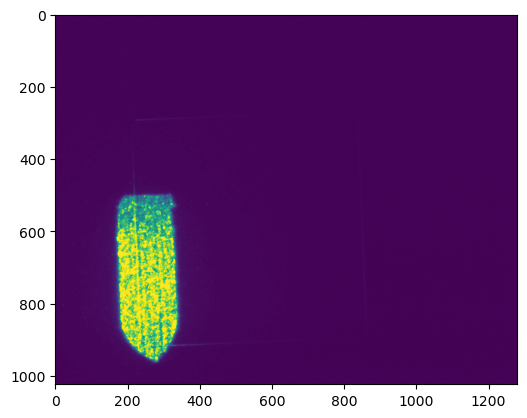

In [16]:
import numpy as np
import matplotlib.pyplot as plt
plt.imshow(img)

In [20]:
minval = np.min(img)
maxval = np.max(img)
print(f"min: {minval}, max: {maxval}")

min: 0, max: 255


  left: 81.12,
 right: 164.16,
   top: 240.48,
bottom: 461.28


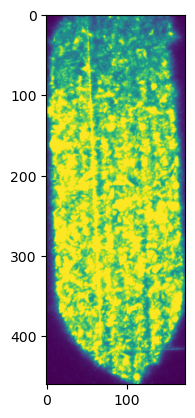

In [ ]:
roi = img > 100

hor, vert = img.shape

left = min(vert - 1, np.argmax(roi.sum(axis=0) > 0))
right = max(0, vert - 1 - np.argmax(roi[:, ::-1].sum(axis=0) > 0))

top = min(hor - 1, np.argmax(roi.sum(axis=1) > 0))
bottom = max(0, hor - 1 - np.argmax(roi[::-1, :].sum(axis=1) > 0))

plt.imshow(img[top:bottom, left:right])
pix_to_um = 0.48
print(f"  left: {left * pix_to_um:.2f},\n"
      f" right: {right * pix_to_um:.2f},\n"
      f"   top: {top * pix_to_um:.2f},\n"
      f"bottom: {bottom * pix_to_um:.2f}")